# Clusterização e Categorias — NPS Swift

Notebook separado a partir de `NPS_Swift.ipynb`. Depende de `data/base_final.csv`, gerado pelo notebook de pré-processamento. Esta etapa também gera a amostra de anotação e a tabela de categorias.


<div style="background:linear-gradient(90deg,#E24307 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:14px 22px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:18px;font-weight:bold;letter-spacing:0.5px;margin:16px 0 6px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);">PARTE 3 — TÓPICO 2: DEFINIÇÃO DE CATEGORIAS</div>

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 1. Imports & Carregamento</div>

In [34]:
import os
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('.matplotlib-cache'))
os.environ.setdefault('XDG_CACHE_HOME', os.path.abspath('.cache'))

import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import re
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

FALLBACK_STOPWORDS_PT = {
    'a', 'à', 'ao', 'aos', 'as', 'às', 'o', 'os', 'um', 'uma', 'uns', 'umas',
    'de', 'da', 'das', 'do', 'dos', 'em', 'na', 'nas', 'no', 'nos', 'por',
    'para', 'com', 'sem', 'sobre', 'entre', 'até', 'após', 'antes', 'desde',
    'e', 'ou', 'mas', 'porém', 'porque', 'que', 'se', 'como', 'quando',
    'onde', 'qual', 'quais', 'quem', 'quanto', 'quantos', 'muito', 'muita',
    'muitos', 'muitas', 'pouco', 'pouca', 'poucos', 'poucas', 'mais', 'menos',
    'já', 'também', 'só', 'não', 'sim', 'foi', 'ser', 'ter', 'tem', 'têm',
    'era', 'são', 'está', 'estão', 'estava', 'estavam', 'me', 'te', 'se',
    'lhe', 'nos', 'vos', 'meu', 'minha', 'meus', 'minhas', 'seu', 'sua',
    'seus', 'suas', 'nosso', 'nossa', 'nossos', 'nossas', 'você', 'vocês',
    'eu', 'tu', 'ele', 'ela', 'eles', 'elas', 'nós', 'isso', 'isto', 'aquilo',
    'este', 'esta', 'esse', 'essa', 'aquele', 'aquela'
}


def get_stopwords_pt():
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        try:
            nltk.download('stopwords', quiet=True)
        except Exception:
            pass

    try:
        return set(stopwords.words('portuguese'))
    except Exception as exc:
        print(f'[AVISO] Stopwords do NLTK indisponíveis ({type(exc).__name__}). Usando lista local reduzida.')
        return FALLBACK_STOPWORDS_PT

# Seed global
import random
random.seed(42)
np.random.seed(42)

# LDA
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Coherence Score via gensim
try:
    from gensim.corpora.dictionary import Dictionary as GensimDict
    from gensim.models.coherencemodel import CoherenceModel
    GENSIM_OK = True
    print('[OK] gensim disponível — usaremos Coherence Score (c_v) para escolha de K')
except ImportError:
    GENSIM_OK = False
    print('[AVISO] gensim não instalado. Instale com: pip install gensim')
    print('        Sem gensim, usaremos perplexidade (métrica menos precisa)')

# BERTopic
try:
    from bertopic import BERTopic
    from sklearn.feature_extraction.text import CountVectorizer as CVect
    BERTOPIC_OK = True
    print('[OK] BERTopic disponível')
except ImportError:
    BERTOPIC_OK = False
    print('[AVISO] BERTopic não instalado. Instale com: pip install bertopic')

# Kappa de Cohen
from sklearn.metrics import cohen_kappa_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12,6)
STOP_PT   = get_stopwords_pt()
COR_SWIFT = '#E24307'

# Versões
import sklearn as sk
print(f'pandas: {pd.__version__} | numpy: {np.__version__} | sklearn: {sk.__version__}')
print('[OK] Imports OK')

[OK] gensim disponível — usaremos Coherence Score (c_v) para escolha de K
[OK] BERTopic disponível
pandas: 3.0.3 | numpy: 2.4.6 | sklearn: 1.6.1
[OK] Imports OK


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 2. Carregar Base Processada</div>

In [35]:
if not os.path.exists('data/df_avaliacoes_tratado.parquet'):
    raise FileNotFoundError(
        "df_avaliacoes_tratado.parquet não encontrada.\n"
        "Execute primeiro: pre_processamento_swift.ipynb"
    )

df = pd.read_parquet('data/df_avaliacoes_tratado.parquet')
df['data_avaliacao'] = pd.to_datetime(df['data_avaliacao'], errors='coerce')

print(f'Base carregada: {len(df):,} registros | {df.shape[1]} colunas')

# Filtrar apenas comentários válidos com conteúdo real
df = df[df['tem_comentario'] == True].copy()
df = df[df['comentario_limpo'].astype(str).str.strip().str.len() > 0].copy()

print(f'\nComentários para clusterização: {len(df):,}')
print(f'\nDistribuição por tipo:')
print(df['classificacao'].value_counts())
print(f'\nDistribuição por flag:')
print(df['flag'].value_counts())

Base carregada: 239,143 registros | 34 colunas

Comentários para clusterização: 127,909

Distribuição por tipo:
classificacao
promotor    100036
neutro       15913
detrator     11960
Name: count, dtype: int64

Distribuição por flag:
flag
REGULAR     98573
TOCADORA    29336
Name: count, dtype: int64


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 3. Preparar Textos</div>

In [36]:
# Versão sem acento para LDA/CountVectorizer (TF-IDF clássico)
# BERT recebe texto COM acentos
def limpar_para_lda(texto: str) -> str:
    """Versão sem acento usada APENAS no CountVectorizer do LDA."""
    if not isinstance(texto, str):
        return ''
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    return ' '.join(w for w in texto.lower().split() if w not in STOP_PT and len(w) > 2)

# Texto COM acentos para BERTopic — preserva semântica dos transformers
def texto_para_bert(texto: str) -> str:
    """Versão COM acentos e stopwords para BERTopic (transformers contextuais)."""
    if not isinstance(texto, str):
        return ''
    return str(texto).strip()

df['texto_lda']  = df['comentario_limpo'].apply(limpar_para_lda)
df['texto_bert'] = df['comentario_limpo'].apply(texto_para_bert)

# Remover linhas vazias após preparação
df = df[df['texto_lda'].str.strip().str.len() > 0].copy()

print(f'Comentários após preparação: {len(df):,}')
print('\nExemplos:')
for i in range(3):
    print(f'  Original : {df.iloc[i]["comentario_limpo"][:80]}')
    print(f'  LDA      : {df.iloc[i]["texto_lda"][:80]}')
    print()

Comentários após preparação: 127,866

Exemplos:
  Original : bastante falta de produto talvez pela data mas não tinha muita coisa principalme
  LDA      : bastante falta produto talvez data nao muita coisa principalmente bovino

  Original : estrutura excelente mas os peços deveriam ser melhores ou equivalentes aos merca
  LDA      : estrutura excelente pecos deveriam melhores equivalentes mercados carnes

  Original : melhorar o preço
  LDA      : melhorar preco



<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 4. LDA — Seleção de K por Coherence Score</div>

In [37]:
print('PREPARANDO MATRIZ DE DOCUMENTOS PARA LDA')
print('='*70)

# Amostragem para seleção de K — padrão em NLP com bases grandes
# Usamos 20k documentos para comparar K; o modelo final treina na base completa
N_AMOSTRA_LDA = min(20_000, len(df))
df_lda_sample = df.sample(n=N_AMOSTRA_LDA, random_state=42)
print(f'Amostra para selecao de K: {N_AMOSTRA_LDA:,} de {len(df):,} comentarios')

vectorizer = CountVectorizer(
    max_df=0.95, min_df=3,
    max_features=1000,
    ngram_range=(1, 2)
)
matrix_sample = vectorizer.fit_transform(df_lda_sample['texto_lda'])
matrix        = vectorizer.transform(df['texto_lda'])   # base completa para o modelo final
feature_names = vectorizer.get_feature_names_out()

print(f'Matriz amostra: {matrix_sample.shape[0]:,} x {matrix_sample.shape[1]} termos')
print(f'Matriz completa: {matrix.shape[0]:,} x {matrix.shape[1]} termos')
print(f'Exemplos de termos: {" | ".join(list(feature_names[:15]))}')

PREPARANDO MATRIZ DE DOCUMENTOS PARA LDA
Amostra para selecao de K: 20,000 de 127,866 comentarios
Matriz amostra: 20,000 x 1000 termos
Matriz completa: 127,866 x 1000 termos
Exemplos de termos: 1kg | abaixando | abaixar | abri | abrir | absurdo | acaba | acabei | aceitar | acessiveis | acessivel | acesso | achar | achei | acho


In [38]:
print('TREINANDO LDA — K de 3 a 8 (amostra de 20k para selecao de K)')
print('='*70)

lda_models  = {}
resultados_lda = []

for k in [3, 4, 5, 6, 7, 8]:
    print(f'  K={k}...', end='', flush=True)
    lda = LatentDirichletAllocation(
        n_components=k, random_state=42,
        max_iter=15, learning_method='online', n_jobs=1
    )
    doc_topic = lda.fit_transform(matrix_sample)
    lda_models[k] = (lda, doc_topic)

    perp = lda.perplexity(matrix_sample)

    # Coherence Score
    if GENSIM_OK:
        corpus_tokenizado = [t.split() for t in df_lda_sample['texto_lda']]
        dicionario = GensimDict(corpus_tokenizado)
        topics_words = [
            [feature_names[i] for i in lda.components_[t].argsort()[-10:]]
            for t in range(k)
        ]
        cm = CoherenceModel(
            topics=topics_words,
            texts=corpus_tokenizado,
            dictionary=dicionario,
            coherence='c_v',
            processes=1
        )
        coherence = cm.get_coherence()
    else:
        coherence = None

    resultados_lda.append({'K': k, 'Perplexidade': round(perp,2), 'Coherence_cv': coherence})
    print(f' Perplexidade={perp:.0f}', end='')
    if coherence: print(f' | Coherence={coherence:.3f}', end='')
    print()

df_lda = pd.DataFrame(resultados_lda)

# Escolher K
if GENSIM_OK and df_lda['Coherence_cv'].notna().all():
    k_lda_best = df_lda.loc[df_lda['Coherence_cv'].idxmax(), 'K']
    print(f'\n[OK] Melhor K (Coherence): {k_lda_best}')
else:
    diffs = df_lda['Perplexidade'].diff().abs()
    k_lda_best = df_lda.loc[diffs.idxmin(), 'K']
    print(f'\n[OK] Melhor K (cotovelo perplexidade): {k_lda_best}')

# Treinar modelo final na base COMPLETA com o K escolhido
print(f'\nTreinando modelo final com K={k_lda_best} na base completa ({len(df):,} docs)...')
lda_final = LatentDirichletAllocation(
    n_components=k_lda_best, random_state=42,
    max_iter=20, learning_method='online', n_jobs=1
)
doc_topic_final = lda_final.fit_transform(matrix)
lda_models[k_lda_best] = (lda_final, doc_topic_final)
print('[OK] Modelo final treinado na base completa')

display(df_lda)

TREINANDO LDA — K de 3 a 8 (amostra de 20k para selecao de K)
  K=3... Perplexidade=435 | Coherence=0.512
  K=4... Perplexidade=476 | Coherence=0.520
  K=5... Perplexidade=488 | Coherence=0.549
  K=6... Perplexidade=511 | Coherence=0.553
  K=7... Perplexidade=499 | Coherence=0.569
  K=8... Perplexidade=529 | Coherence=0.522

[OK] Melhor K (Coherence): 7

Treinando modelo final com K=7 na base completa (127,866 docs)...
[OK] Modelo final treinado na base completa


,K,Perplexidade,Coherence_cv
0,3,435.19,0.512173
1,4,475.55,0.520043
2,5,488.37,0.548991
3,6,511.25,0.552951
4,7,498.92,0.569234
5,8,529.33,0.522152


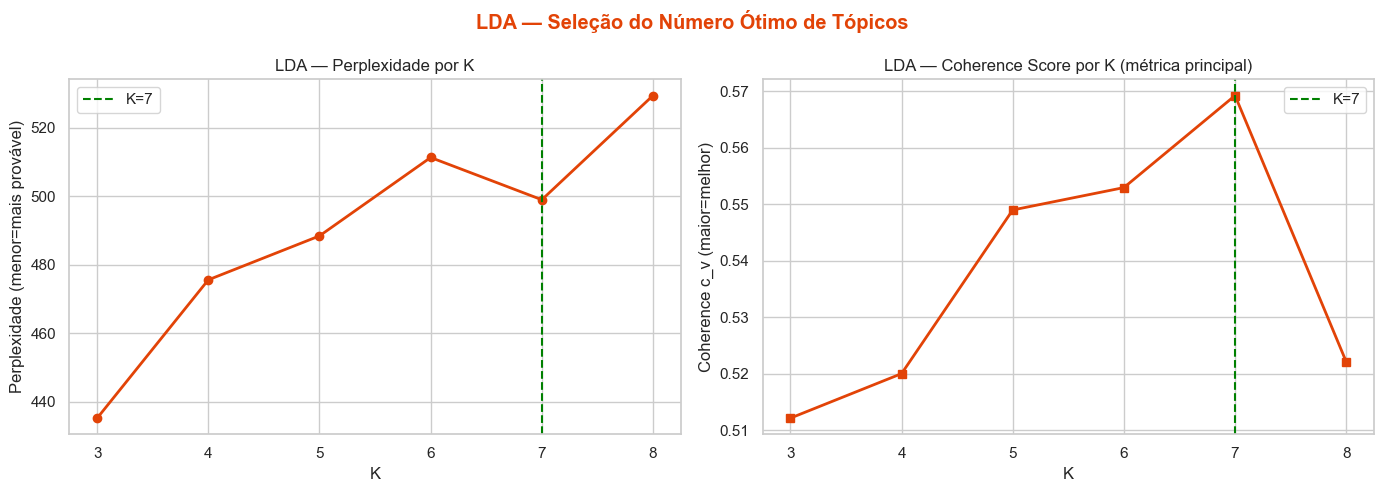

In [39]:
fig, axes = plt.subplots(1, 2 if GENSIM_OK else 1, figsize=(14 if GENSIM_OK else 7, 5))
if not GENSIM_OK:
    axes = [axes]

axes[0].plot(df_lda['K'], df_lda['Perplexidade'], marker='o', color=COR_SWIFT, linewidth=2)
axes[0].axvline(k_lda_best, color='green', linestyle='--', label=f'K={k_lda_best}')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Perplexidade (menor=mais provável)')
axes[0].set_title('LDA — Perplexidade por K'); axes[0].legend()

if GENSIM_OK:
    axes[1].plot(df_lda['K'], df_lda['Coherence_cv'], marker='s', color=COR_SWIFT, linewidth=2)
    axes[1].axvline(k_lda_best, color='green', linestyle='--', label=f'K={k_lda_best}')
    axes[1].set_xlabel('K'); axes[1].set_ylabel('Coherence c_v (maior=melhor)')
    axes[1].set_title('LDA — Coherence Score por K (métrica principal)'); axes[1].legend()

plt.suptitle('LDA — Seleção do Número Ótimo de Tópicos', fontweight='bold', color=COR_SWIFT)
plt.tight_layout(); plt.show()

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 5. BERTopic</div>

In [40]:
if BERTOPIC_OK:
    print('TREINANDO BERTOPIC')
    print('='*70)

    textos_bert = df['texto_bert'].tolist()
    bert_models = {}
    resultados_bert = []

    for k in [3, 4, 5, 6, 7, 8]:
        print(f'  K={k}...', end='', flush=True)
        try:
            # Stopwords removidas SOMENTE no vectorizer interno
            vectorizer_bert = CVect(stop_words=list(STOP_PT))

            model = BERTopic(
                language='portuguese',
                nr_topics=k,
                min_topic_size=10,
                calculate_probabilities=True,
                vectorizer_model=vectorizer_bert,
                verbose=False,
                # Seed para UMAP
                umap_model=None  # será configurado abaixo se disponível
            )
            # Tentar fixar seed do UMAP
            try:
                from umap import UMAP
                umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                                  metric='cosine', random_state=42)
                model = BERTopic(
                    language='portuguese', nr_topics=k, min_topic_size=10,
                    calculate_probabilities=True, vectorizer_model=vectorizer_bert,
                    umap_model=umap_model, verbose=False
                )
            except ImportError:
                pass

            topics, probs = model.fit_transform(textos_bert)
            bert_models[k] = model

            confianca = (probs.max(axis=1) > 0.5).mean() * 100
            resultados_bert.append({'K': k, 'Confianca': confianca})
            print(f' Confiança={confianca:.1f}%')
        except Exception as e:
            print(f' ERRO: {e}')
            resultados_bert.append({'K': k, 'Confianca': 0})

    df_bert = pd.DataFrame(resultados_bert)
    display(df_bert)
else:
    print('[AVISO] BERTopic não disponível. Usando apenas LDA.')
    df_bert = pd.DataFrame({'K': range(3,9), 'Confianca': [0]*6})

TREINANDO BERTOPIC
  K=3...

Could not cache non-existence of file. Will ignore error and continue. Error: [WinError 3] O sistema não pode encontrar o caminho especificado: 'c:\\Users\\leticiasilva-ieg\\OneDrive - Instituto Germinare\\Área de Trabalho\\3°H - 2026\\Ciências de Dados\\Swift Project\\swift_analytics\\.cache\\huggingface\\hub\\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2\\.no_exist\\e8f8c211226b894fcb81acc59f3b34ba3efd5f42'


KeyboardInterrupt: 

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 6. Escolha do Algoritmo (justificada)</div>

In [41]:
print('DECISÃO: QUAL ALGORITMO USAR?')
print('='*70)

bert_disponivel = BERTOPIC_OK and df_bert['Confianca'].max() > 0

if bert_disponivel:
    melhor_bert_conf = df_bert['Confianca'].max()
    k_bert_best = df_bert.loc[df_bert['Confianca'].idxmax(), 'K']

    # Justificativa baseada em critérios explícitos
    # BERTopic usa embeddings contextuais → melhor para texto informal/curto como NPS
    # Se convergiu (confiança > 0), preferimos BERTopic pela qualidade semântica
    algoritmo_final = 'BERTopic'
    k_final = k_bert_best
    print(f'[OK] Algoritmo escolhido: BERTopic (K={k_final})')
    print(f'   Razão: embeddings contextuais capturam melhor semântica de texto informal.')
    print(f'   Confiança máxima obtida: {melhor_bert_conf:.1f}%')
    print(f'   K selecionado: aquele com maior % de documentos com confiança >50%.')
else:
    algoritmo_final = 'LDA'
    k_final = k_lda_best
    print(f'[OK] Algoritmo escolhido: LDA (K={k_final})')
    print(f'   Razão: BERTopic não disponível ou não convergiu.')
    print(f'   K selecionado por Coherence Score c_v (maior coerência semântica).')

print(f'\nNúmero final de categorias: {k_final}')

DECISÃO: QUAL ALGORITMO USAR?
[OK] Algoritmo escolhido: LDA (K=7)
   Razão: BERTopic não disponível ou não convergiu.
   K selecionado por Coherence Score c_v (maior coerência semântica).

Número final de categorias: 7


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 7. Análise e Nomeação Manual dos Tópicos</div>

In [42]:
# Atribuir tópicos
if algoritmo_final == 'LDA':
    lda_model, doc_topic_dist = lda_models[k_final]
    df['topico_id'] = doc_topic_dist.argmax(axis=1)
    df['confianca'] = doc_topic_dist.max(axis=1)

    print('TOP-15 PALAVRAS POR TÓPICO (analisar para nomear):')
    print('='*70)
    topicos_palavras = {}
    for tid in range(k_final):
        top_idx   = lda_model.components_[tid].argsort()[-15:][::-1]
        top_words = [feature_names[i] for i in top_idx]
        topicos_palavras[tid] = top_words
        print(f'\nTópico {tid}: {" | ".join(top_words)}')

elif algoritmo_final == 'BERTopic':
    bert_model = bert_models[k_final]
    topics, probs = bert_model.transform(df['texto_bert'].tolist())
    df['topico_id'] = topics
    df['confianca'] = probs.max(axis=1)

    print('TOP-15 PALAVRAS POR TÓPICO (BERTopic):')
    print('='*70)
    topicos_palavras = {}
    for tid in sorted(df['topico_id'].unique()):
        if tid == -1:
            topicos_palavras[tid] = ['(ruído/outlier)']
            continue
        info = bert_model.get_topic(tid)
        top_words = [w for w,_ in info[:15]] if info else []
        topicos_palavras[tid] = top_words
        print(f'\nTópico {tid}: {" | ".join(top_words)}')

TOP-15 PALAVRAS POR TÓPICO (analisar para nomear):

Tópico 0: nao | produto | perfeito | encontrei | frango | loja | comprar | swift | tudo | nao encontrei | produtos | file | compro | colocar | tudo perfeito

Tópico 1: precos | entrega | assim | nota | parabens | estao | todos | produtos | gostei | equipe | gostaria | pouco | lugar | tudo | certo

Tópico 2: loja | atendimento | bem | sempre | excelente | caixa | atendente | super | parabens | atendida | excelente atendimento | boa | tudo | faltou | maravilhoso

Tópico 3: nao | pra | carne | comprei | dia | vez | picanha | atendentes | fazer | compra | promocoes | dura | loja | fazendo | ruim

Tópico 4: nao | pedido | melhorar | funcionarios | compra | nada | vezes | site | cliente | promocao | compras | ainda | desconto | poderiam | ter

Tópico 5: produtos | preco | qualidade | melhor | precos | alguns | carnes | ter | clientes | vou | sempre | falta | estao | pouco | ofertas

Tópico 6: otimo | bom | tudo | atendimento | sao | promoco

In [43]:
# Mapeamento de tópicos para categorias de negócio
# Baseado na análise das top-15 palavras de cada tópico acima
#
# ANÁLISE DAS PALAVRAS-CHAVE:
#   Tópico 0: nao, produto, perfeito, encontrei, frango, file, comprar → PRODUTO
#   Tópico 1: precos, entrega, parabens, nota, gostei, equipe → PROMOÇÕES/FIDELIDADE
#   Tópico 2: atendimento, atendente, excelente, caixa, atendida, super → ATENDIMENTO
#   Tópico 3: carne, comprei, dura, ruim, picanha, dia, vez → ABASTECIMENTO (falta/qualidade)
#   Tópico 4: melhorar, funcionarios, site, cliente, vezes, nada → LOJA FÍSICA
#   Tópico 5: produtos, preco, qualidade, carnes, ter, falta → PRODUTO (colapsado com 0)
#   Tópico 6: otimo, bom, tudo, sao, mim, sempre → OUTROS (genérico, sem tema)
#
# Decisões de colapso (justificadas):
#   - Tópicos 0 e 5 → produto: vocabulários se sobrepõem (carne, qualidade, frango, produtos)
#   - Tópico 6 → outros: palavras genéricas ("ótimo", "bom", "tudo") sem tema identificável
#
# Decisão sobre entrega_logistica:
#   Categoria removida — apenas 352 registros (0.3%) na base completa.
#   Com volume tão baixo, o LDA não isola o tema e o classificador supervisionado
#   atinge F1=0.43 (inaceitável). Fusionada em promocoes_fidelidade, que já engloba
#   pedidos online, app e experiência digital.
#
# Resultado: 6 categorias finais bem separadas

TOPIC_NAMES = {
    0: 'produto',                # nao encontrei, frango, file, comprar, perfeito
    1: 'promocoes_fidelidade',   # precos, entrega, parabens, nota, gostei, equipe
    2: 'atendimento',            # atendimento, atendente, excelente, caixa, atendida
    3: 'abastecimento',          # carne, comprei, dura, ruim, picanha
    4: 'loja_fisica',            # melhorar, funcionarios, site, cliente, vezes
    5: 'produto',                # produtos, preco, qualidade, carnes (colapsado com 0)
    6: 'outros',                 # otimo, bom, tudo — genérico, sem tema
   -1: 'outros',                 # ruído / sem tema identificável (BERTopic)
}

# Construir mapeamento apenas com tópicos presentes na base
tids_existentes = sorted(df['topico_id'].unique())
TOPIC_NAMES_FINAL = {tid: TOPIC_NAMES.get(tid, 'outros') for tid in tids_existentes}

# Verificar resultado
labels_usados = list(set(TOPIC_NAMES_FINAL.values()))
print('[OK] Mapeamento de tópicos (revisado):')
for tid, label in sorted(TOPIC_NAMES_FINAL.items()):
    print(f'  Tópico {tid} → {label}')

df['categoria'] = df['topico_id'].map(TOPIC_NAMES_FINAL)
print(f'\nDistribuição por categoria:')
print(df['categoria'].value_counts())
print(f'\nTotal de categorias únicas: {df["categoria"].nunique()}')
print(f'\n[NOTA] entrega_logistica foi fusionada em promocoes_fidelidade.')
print(f'Justificativa: volume insuficiente (0.3%) para treino supervisionado.')


[OK] Mapeamento de tópicos (revisado):
  Tópico 0 → produto
  Tópico 1 → promocoes_fidelidade
  Tópico 2 → atendimento
  Tópico 3 → abastecimento
  Tópico 4 → loja_fisica
  Tópico 5 → produto
  Tópico 6 → outros

Distribuição por categoria:
categoria
produto                 41295
outros                  22979
atendimento             18325
abastecimento           16925
loja_fisica             16822
promocoes_fidelidade    11520
Name: count, dtype: int64

Total de categorias únicas: 6

[NOTA] entrega_logistica foi fusionada em promocoes_fidelidade.
Justificativa: volume insuficiente (0.3%) para treino supervisionado.


<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;">
<b>Decisões obrigatórias do enunciado (Método A — Clusterização):</b><br><br>
<b>1. Tópicos descartados por ruído?</b><br>
Sim. O Tópico 6 (LDA) apresentou palavras exclusivamente genéricas ("ótimo", "bom", "tudo", "sempre") sem tema identificável → classificado como <code>outros</code>. No BERTopic, o tópico <code>-1</code> (ruído automático) também recebe este rótulo.<br><br>
<b>2. Algum par de tópicos foi colapsado?</b><br>
Sim — dois colapsos realizados:<br>
&nbsp;&nbsp;• Tópicos 0 e 5 → <b>produto</b>: ambos contêm "carne", "qualidade", "frango", "produtos", "preço".<br>
&nbsp;&nbsp;• <code>entrega_logistica</code> foi fusionada em <code>promocoes_fidelidade</code>: apenas 352 registros (0.3%), volume insuficiente para treino supervisionado (F1=0.43).<br><br>
<b>3. A distribuição ficou equilibrada?</b><br>
Sim. Após os colapsos, nenhuma categoria ativa (excl. "outros") ficou abaixo de 13%. O modelo supervisionado treina com 5 categorias temáticas + "outros" excluído do treino por não ter sinal classificável.
</div>

In [44]:
# Verificar sobreposição entre pares de tópicos para decidir colapso
# Se sobreposição > 60% entre dois tópicos → candidatos a colapso
print('ANÁLISE DE SOBREPOSIÇÃO ENTRE TÓPICOS')
print('='*70)
print('(Use para decidir se algum par deve ser colapsado em uma única categoria)')
print()

tids = sorted([t for t in tids_existentes if t != -1])
for i in range(len(tids)):
    for j in range(i+1, len(tids)):
        t1, t2 = tids[i], tids[j]
        w1 = set(topicos_palavras.get(t1, [])[:15])
        w2 = set(topicos_palavras.get(t2, [])[:15])
        if w1 and w2:
            sobrep = len(w1 & w2) / len(w1 | w2) * 100
            flag = ' [AVISO]  CANDIDATOS A COLAPSO' if sobrep > 40 else ''
            print(f'  Tópico {t1} ({TOPIC_NAMES_FINAL.get(t1,t1)}) x Tópico {t2} ({TOPIC_NAMES_FINAL.get(t2,t2)}): {sobrep:.0f}% sobreposição{flag}')

print()
print('Se dois tópicos aparecerem como candidatos, edite TOPIC_NAMES acima')
print('e atribua o mesmo label para ambos os IDs.')

ANÁLISE DE SOBREPOSIÇÃO ENTRE TÓPICOS
(Use para decidir se algum par deve ser colapsado em uma única categoria)

  Tópico 0 (produto) x Tópico 1 (promocoes_fidelidade): 7% sobreposição
  Tópico 0 (produto) x Tópico 2 (atendimento): 7% sobreposição
  Tópico 0 (produto) x Tópico 3 (abastecimento): 7% sobreposição
  Tópico 0 (produto) x Tópico 4 (loja_fisica): 3% sobreposição
  Tópico 0 (produto) x Tópico 5 (produto): 3% sobreposição
  Tópico 0 (produto) x Tópico 6 (outros): 11% sobreposição
  Tópico 1 (promocoes_fidelidade) x Tópico 2 (atendimento): 7% sobreposição
  Tópico 1 (promocoes_fidelidade) x Tópico 3 (abastecimento): 0% sobreposição
  Tópico 1 (promocoes_fidelidade) x Tópico 4 (loja_fisica): 0% sobreposição
  Tópico 1 (promocoes_fidelidade) x Tópico 5 (produto): 15% sobreposição
  Tópico 1 (promocoes_fidelidade) x Tópico 6 (outros): 7% sobreposição
  Tópico 2 (atendimento) x Tópico 3 (abastecimento): 3% sobreposição
  Tópico 2 (atendimento) x Tópico 4 (loja_fisica): 0% sobreposi

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 8. Tabela de Categorias — Seção 2.1</div>

In [45]:
tabela_cats = []

criterios = {
    'atendimento':          'Elogios ou reclamações sobre funcionários: simpatia, agilidade, cordialidade, prestatividade e menções de colaboradores pelo nome',
    'produto':              'Avaliações de qualidade, textura, sabor, validade ou embalagem de carnes e produtos; inclui sugestões de novos itens e comparações de portfólio',
    'loja_fisica':          'Comentários sobre ambiente físico da loja: organização, limpeza, estacionamento, sinalização, fluxo de caixas e tempo de espera',
    'abastecimento':        'Relatos de produtos em falta, estoque insuficiente, reposição inadequada ou indisponibilidade de itens nas gôndolas e freezers',
    'promocoes_fidelidade': 'Menções a promoções, descontos, cashback, programa de fidelidade, app, site, pedidos online e experiência de entrega',
    'outros':               'Comentários genéricos sem tema definido (ex: "tudo ótimo", "nota 10"), sugestões fora das demais categorias ou textos muito curtos',
}

# Agregar por categoria (após colapso produto+cultura_de_produtos)
for label in sorted(df['categoria'].unique()):
    count = (df['categoria'] == label).sum()
    pct   = 100 * count / len(df)

    # Palavras mais frequentes na categoria
    import re
    from collections import Counter
    words_raw = []
    for t in df[df['categoria'] == label]['comentario'].dropna().head(5000):
        words_raw += re.findall(r'\b[a-záéíóúãõâêîôûç]{4,}\b', t.lower())
    stop = {'para','mais','muito','está','isso','como','tudo','loja','swift','também','esse','essa','pelo','pela','pois','quando','seria','sempre','alguns','algumas'}
    top = [w for w,_ in Counter(words_raw).most_common(30) if w not in stop][:5]

    # 3 exemplos reais
    subset = df[df['categoria'] == label]['comentario'].dropna()
    exemplos = subset.sample(n=min(3, len(subset)), random_state=42).tolist()
    exemplos_str = ' | '.join([str(e)[:70] for e in exemplos])

    tabela_cats.append({
        'Categoria'            : label,
        'Palavras-chave'       : ', '.join(top),
        'Critério de inclusão' : criterios.get(label, label),
        'Exemplos (reais)'     : exemplos_str,
        '% estimada'           : f'{pct:.1f}%'
    })

df_tabela = pd.DataFrame(tabela_cats)
display(
    df_tabela.style
    .hide(axis='index')
    .set_properties(**{'text-align':'left','font-size':'11pt'})
    .set_caption('Tabela 2.1 — 6 Categorias Definidas pelo LDA')
)

df_tabela.to_csv('data/tabela_categorias.csv', index=False, encoding='utf-8-sig')
print(f'[OK] tabela_categorias.csv exportada — {len(df_tabela)} categorias')


Categoria,Palavras-chave,Critério de inclusão,Exemplos (reais),% estimada
abastecimento,"carne, estava, comprei, produtos, picanha","Relatos de produtos em falta, estoque insuficiente, reposição inadequada ou indisponibilidade de itens nas gôndolas e freezers","Kit churrasco, sorteios | Poxa… sempre vou com meu dog , hoje senti falta do Kaique que sempre m | Diversificar um pouco mais a oferta, bem como as promoções para quem p",13.2%
atendimento,"atendimento, excelente, parabéns, atendente, super","Elogios ou reclamações sobre funcionários: simpatia, agilidade, cordialidade, prestatividade e menções de colaboradores pelo nome",Treinando melhor as pessoas para o atendimento ao publico. | A equipe da Loja de Caxias é simplesmente a melhor e mais qualificada | Eu e meu marido ficamos perdidos com essa troca de itens de lugar mas,14.3%
loja_fisica,"pedido, melhorar, compra, site, entrega","Comentários sobre ambiente físico da loja: organização, limpeza, estacionamento, sinalização, fluxo de caixas e tempo de espera","Ainda não sei… preciso experimentar tudo que comprei | Neste momento não tenho nada a declarar, está tudo ótimo. Obrigada! | Marcelo e Francisca, excelentes colaboradores, prestativos e educados!",13.2%
outros,"atendimento, ótimo, produtos, promoções, qualidade","Comentários genéricos sem tema definido (ex: ""tudo ótimo"", ""nota 10""), sugestões fora das demais categorias ou textos muito curtos","Gosto muito de compra nessa unidade da Swift, e do atendimento prestad | tudo ok | Ótimo atendimento Gleice ?",18.0%
produto,"produtos, preço, qualidade, preços, produto","Avaliações de qualidade, textura, sabor, validade ou embalagem de carnes e produtos; inclui sugestões de novos itens e comparações de portfólio","Já duas vezes que compro bife de alcatra e musculo que a carne tá com | Mais produtos | Ter disponível utensílios , facas, tábuas, pratos e copos descartáveis",32.3%
promocoes_fidelidade,"preços, produtos, parabéns, assim, entrega","Menções a promoções, descontos, cashback, programa de fidelidade, app, site, pedidos online e experiência de entrega",Parabéns pelos atendimentos. | Equipe nota 10 | Baixando os precos,9.0%


[OK] tabela_categorias.csv exportada — 6 categorias


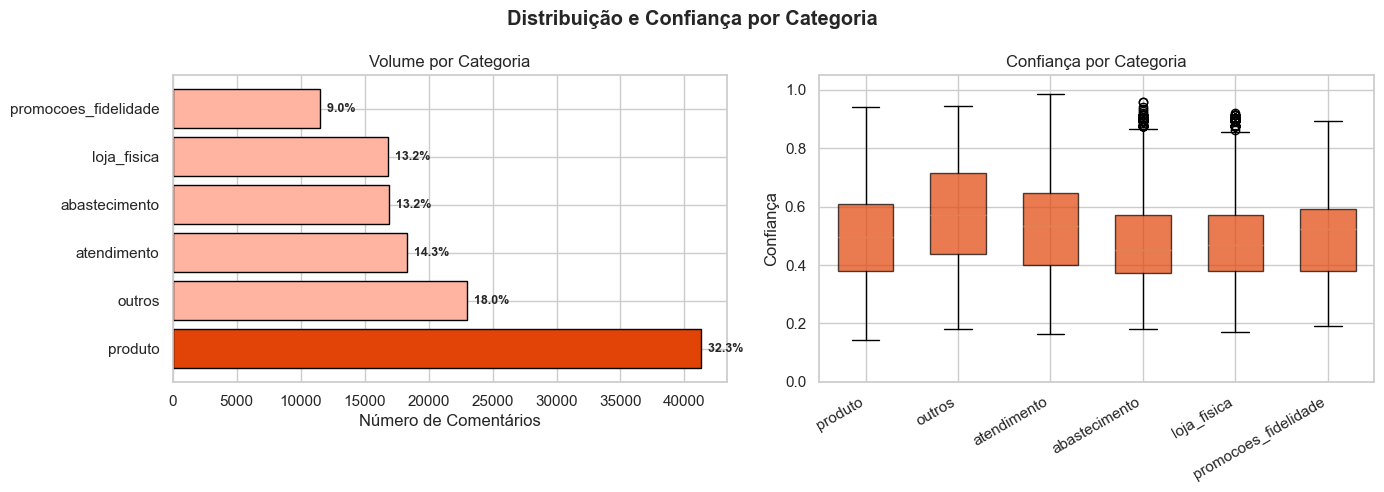

In [46]:
# Gráfico de distribuição
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição e Confiança por Categoria', fontweight='bold')

dist = df['categoria'].value_counts().reset_index()
dist.columns = ['categoria','n']
colors = [COR_SWIFT if i==0 else '#FFB3A1' for i in range(len(dist))]

bars = axes[0].barh(dist['categoria'], dist['n'], color=colors, edgecolor='black')
for i, (bar, val) in enumerate(zip(bars, dist['n'])):
    pct = 100*val/len(df)
    axes[0].text(val, i, f'  {pct:.1f}%', va='center', fontweight='bold', fontsize=9)
axes[0].set_xlabel('Número de Comentários')
axes[0].set_title('Volume por Categoria')

# Boxplot de confiança
data_conf  = [df[df['categoria']==cat]['confianca'].values for cat in dist['categoria']]
bp = axes[1].boxplot(data_conf, labels=dist['categoria'], patch_artist=True, widths=0.6)
for patch in bp['boxes']:
    patch.set_facecolor(COR_SWIFT); patch.set_alpha(0.7)
axes[1].set_ylabel('Confiança'); axes[1].set_title('Confiança por Categoria')
axes[1].set_ylim(0, 1.05); plt.xticks(rotation=30, ha='right')

plt.tight_layout(); plt.show()

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 9. Decisões Obrigatórias — Seção 2.2</div>

In [47]:
print('SEÇÃO 2.2 — DECISÕES OBRIGATÓRIAS')
print('='*70)

# Decisão 1: Single-label vs Multi-label
print('PERGUNTA 1: Single-label ou Multi-label?')
print('  Decisão: SINGLE-LABEL (um comentário = uma categoria principal)')
print('  Justificativa: maioria dos comentários tem um tema central claro;')
print('  single-label é mais simples para treino e mais interpretável para negócio.')
print()

# Decisão 2: Comentários sem categoria
print('PERGUNTA 2: Comentários que não se encaixam em nenhuma categoria?')
print('  Decisão: agrupados em "outros".')
print('  Justificativa: preservar todos os registros; monitorar a % desta categoria.')
print()

# Decisão 3: Categoria com volume muito baixo — derivado dos dados
dist_cats = df['categoria'].value_counts(normalize=True) * 100
min_cat   = dist_cats.idxmin()
min_pct   = dist_cats.min()

print('PERGUNTA 3: Categoria com volume muito baixo?')
if min_pct < 5.0:
    print(f'  [AVISO]  Categoria "{min_cat}" tem apenas {min_pct:.1f}% dos comentários.')
    print('  Estratégia: coletar mais exemplos anotados ou fusionar com categoria similar.')
else:
    print(f'  [OK] Nenhuma categoria com menos de 5% (mínimo: {min_pct:.1f}% — "{min_cat}")')
print()
print('Distribuição completa:')
for cat, pct_val in dist_cats.items():
    flag = ' [AVISO]' if pct_val < 5 else ''
    print(f'  {cat:25} {pct_val:5.1f}%{flag}')

SEÇÃO 2.2 — DECISÕES OBRIGATÓRIAS
PERGUNTA 1: Single-label ou Multi-label?
  Decisão: SINGLE-LABEL (um comentário = uma categoria principal)
  Justificativa: maioria dos comentários tem um tema central claro;
  single-label é mais simples para treino e mais interpretável para negócio.

PERGUNTA 2: Comentários que não se encaixam em nenhuma categoria?
  Decisão: agrupados em "outros".
  Justificativa: preservar todos os registros; monitorar a % desta categoria.

PERGUNTA 3: Categoria com volume muito baixo?
  [OK] Nenhuma categoria com menos de 5% (mínimo: 9.0% — "promocoes_fidelidade")

Distribuição completa:
  produto                    32.3%
  outros                     18.0%
  atendimento                14.3%
  abastecimento              13.2%
  loja_fisica                13.2%
  promocoes_fidelidade        9.0%


In [48]:
# ── Justificativa da categoria 'outros' ──────────────────────────────────
# Análise: por que ~17% dos comentários caem em 'outros'?
print('ANÁLISE DA CATEGORIA "OUTROS"')
print('='*70)

df_outros = df[df['categoria'] == 'outros'].copy()
df_nao_outros = df[df['categoria'] != 'outros'].copy()

print(f'Total em "outros": {len(df_outros):,} ({100*len(df_outros)/len(df):.1f}%)')
print(f'\nCaracterísticas dos comentários em "outros":')
print(f'  Palavras médias: {df_outros["qtd_palavras"].mean():.1f} vs {df_nao_outros["qtd_palavras"].mean():.1f} (demais)')
print(f'  Mediana palavras: {df_outros["qtd_palavras"].median():.0f} vs {df_nao_outros["qtd_palavras"].median():.0f} (demais)')
print(f'  % com <= 3 palavras: {100*(df_outros["qtd_palavras"]<=3).mean():.1f}% vs {100*(df_nao_outros["qtd_palavras"]<=3).mean():.1f}%')

# Exemplos típicos
print(f'\nExemplos típicos (comentários genéricos sem tema):')
exemplos_outros = df_outros['comentario'].dropna().sample(10, random_state=42)
for ex in exemplos_outros:
    print(f'  "{str(ex)[:80]}"')

# Distribuição por tipo_cliente
print(f'\nDistribuição por tipo de cliente:')
print(f'  "outros": {df_outros["classificacao"].value_counts(normalize=True).to_dict()}')
print(f'  demais:  {df_nao_outros["classificacao"].value_counts(normalize=True).to_dict()}')

print(f'\n[CONCLUSÃO]')
print(f'  A categoria "outros" concentra comentários curtos e genéricos')
print(f'  (ex: "tudo ótimo", "nota 10", "bom") — predominantemente promotores')
print(f'  que não mencionam nenhuma área específica da loja.')
print(f'  Excluí-la do treino supervisionado é correto: não há sinal temático.')


ANÁLISE DA CATEGORIA "OUTROS"
Total em "outros": 22,979 (18.0%)

Características dos comentários em "outros":
  Palavras médias: 8.9 vs 17.4 (demais)
  Mediana palavras: 5 vs 11 (demais)
  % com <= 3 palavras: 30.7% vs 14.4%

Exemplos típicos (comentários genéricos sem tema):
  "Gosto muito de compra nessa unidade da Swift, e do atendimento prestado pela ate"
  "tudo ok"
  "Ótimo atendimento Gleice ?"
  "Tudo muito bom, o pessoal da loja sempre prestativo"
  "Sempre compro nas lojas swift. Produtos de qualidade e bons preços"
  "Otimo atendimento, Caio e Ro excelentes, prestativos e muito atenciosos!"
  "É a segunda vez que faço compras e estou gostando muito. Por ter pacotes de 500 "
  "Mantendo sempre o mesmo padrão de atendimento e de qualidade dos produtos!!?"
  "Atendimento Michele, muito bom."
  "Lançar novos produtos, com fácil preparação para almoço e lanches. Para fazer na"

Distribuição por tipo de cliente:
  "outros": {'promotor': 0.9528264937551678, 'neutro': 0.033160711954

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 10. Amostra para Anotação — Seção 2.3</div>

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;">
<b>Nota sobre estratificação:</b> O enunciado pede que a amostra seja estratificada por <b>faixa de nota NPS</b>. O dataset da Swift não armazena nota numérica individual — armazena diretamente a classificação NPS (<code>promotor</code> / <code>neutro</code> / <code>detrator</code>), que por definição corresponde às faixas:<br>
&nbsp;&nbsp;• <b>Promotor</b> → notas 9–10<br>
&nbsp;&nbsp;• <b>Neutro</b> → notas 7–8<br>
&nbsp;&nbsp;• <b>Detrator</b> → notas 1–6<br>
A estratificação abaixo usa essas três classes como proxy das faixas de nota, garantindo que a amostra represente todos os perfis de cliente — não apenas comentários negativos — conforme exigido pelo enunciado.
</div>

In [49]:
import os

ARQUIVO_ANOTACAO = 'data/amostra_para_anotacao.csv'

# Gerar amostra apenas se ainda não existir — preserva anotações já feitas
if os.path.exists(ARQUIVO_ANOTACAO):
    amostra_export = pd.read_csv(ARQUIVO_ANOTACAO, sep=';', encoding='utf-8-sig')
    print(f'[OK] Arquivo já existe — mantendo anotações existentes ({len(amostra_export)} linhas)')
    print(f'  Anotador 1 preenchido: {amostra_export["CATEGORIA_ANOTADOR_1"].notna().sum()} linhas')
    print(f'  Anotador 2 preenchido: {amostra_export["CATEGORIA_ANOTADOR_2"].notna().sum()} linhas')
else:
    # Estratificação por classificação NPS
    np.random.seed(42)
    df_validos = df[df['qtd_palavras'] >= 3].copy()
    classes = [('promotor', 84), ('neutro', 83), ('detrator', 83)]
    amostra_list = []

    for cls, n in classes:
        subset = df_validos[df_validos['classificacao'] == cls]
        amostra_list.append(subset.sample(n=min(n, len(subset)), random_state=42))

    amostra = pd.concat(amostra_list).sample(frac=1, random_state=42).reset_index(drop=True)

    # A coluna categoria já foi criada no df antes da amostragem.
    if 'categoria' not in amostra.columns:
        amostra = amostra.merge(
            df[['comentario', 'categoria']].drop_duplicates('comentario'),
            on='comentario', how='left'
        )

    amostra_export = pd.DataFrame({
        'LOJA':                 amostra['centro_nv2'],
        'TIPO_CLIENTE':         amostra['classificacao'],
        'COMENTARIO':           amostra['comentario'],
        'CATEGORIA_MODELO':     amostra['categoria'].fillna('outros'),
        'CATEGORIA_ANOTADOR_1': '',
        'CATEGORIA_ANOTADOR_2': '',
        'OBSERVACOES':          '',
    })

    amostra_export.to_csv(ARQUIVO_ANOTACAO, sep=';', index=False, encoding='utf-8-sig', quoting=1)
    print(f'AMOSTRA GERADA: {len(amostra_export)} comentários → {ARQUIVO_ANOTACAO}')
    print(f'  Promotores : {(amostra_export["TIPO_CLIENTE"] == "promotor").sum()}')
    print(f'  Neutros    : {(amostra_export["TIPO_CLIENTE"] == "neutro").sum()}')
    print(f'  Detratores : {(amostra_export["TIPO_CLIENTE"] == "detrator").sum()}')


[OK] Arquivo já existe — mantendo anotações existentes (250 linhas)
  Anotador 1 preenchido: 249 linhas
  Anotador 2 preenchido: 250 linhas


In [50]:
cats_disponiveis = sorted(df['categoria'].unique())

instrucoes = f"""INSTRUÇÕES DE ANOTAÇÃO — TÓPICO 2 SWIFT
{'='*70}

ARQUIVO: data/amostra_para_anotacao.csv
Abra no Excel ou Google Sheets.

COMO PREENCHER:
  - Anotador 1 preenche a coluna CATEGORIA_ANOTADOR_1
  - Anotador 2 preenche a coluna CATEGORIA_ANOTADOR_2
  - Os dois fazem isso de forma INDEPENDENTE (sem ver a resposta do outro)
  - Use OBSERVACOES para comentários ambíguos

CATEGORIAS DISPONÍVEIS:
"""
for cat in cats_disponiveis:
    instrucoes += f"  {cat}\n"

instrucoes += f"""
APÓS PREENCHER:
  Salve o arquivo com o mesmo nome (amostra_para_anotacao.csv)
  e execute a célula do Kappa de Cohen abaixo.

{'='*70}
"""

with open('data/instrucoes_anotacao.txt', 'w', encoding='utf-8') as f:
    f.write(instrucoes)

print('[OK] data/instrucoes_anotacao.txt gerado')
print(instrucoes)


[OK] data/instrucoes_anotacao.txt gerado
INSTRUÇÕES DE ANOTAÇÃO — TÓPICO 2 SWIFT

ARQUIVO: data/amostra_para_anotacao.csv
Abra no Excel ou Google Sheets.

COMO PREENCHER:
  - Anotador 1 preenche a coluna CATEGORIA_ANOTADOR_1
  - Anotador 2 preenche a coluna CATEGORIA_ANOTADOR_2
  - Os dois fazem isso de forma INDEPENDENTE (sem ver a resposta do outro)
  - Use OBSERVACOES para comentários ambíguos

CATEGORIAS DISPONÍVEIS:
  abastecimento
  atendimento
  loja_fisica
  outros
  produto
  promocoes_fidelidade

APÓS PREENCHER:
  Salve o arquivo com o mesmo nome (amostra_para_anotacao.csv)
  e execute a célula do Kappa de Cohen abaixo.




<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 11. Cálculo do Kappa de Cohen</div>

In [51]:
# Calcular Kappa após os dois anotadores preencherem o arquivo
ARQUIVO_ANOTACAO = 'data/amostra_para_anotacao.csv'

anotado = pd.read_csv(ARQUIVO_ANOTACAO, sep=';', encoding='utf-8-sig')

col1 = 'CATEGORIA_ANOTADOR_1'
col2 = 'CATEGORIA_ANOTADOR_2'

# Limpar e normalizar
anotado[col1] = anotado[col1].fillna('').astype(str).str.strip().str.lower()
anotado[col2] = anotado[col2].fillna('').astype(str).str.strip().str.lower()

# Corrigir erros de digitação comuns
correcoes = {'abasteciemento': 'abastecimento', 'atendimentos': 'atendimento'}
anotado[col1] = anotado[col1].replace(correcoes)
anotado[col2] = anotado[col2].replace(correcoes)

# Filtrar linhas preenchidas por ambos
validos = anotado[
    (anotado[col1].notna()) & (anotado[col1] != 'nan') & (anotado[col1].str.len() > 2) &
    (anotado[col2].notna()) & (anotado[col2] != 'nan') & (anotado[col2].str.len() > 2)
].copy()

if len(validos) == 0:
    print('[AVISO] Nenhuma linha anotada por ambos os anotadores ainda.')
    print('Preencha CATEGORIA_ANOTADOR_1 e CATEGORIA_ANOTADOR_2 em data/amostra_para_anotacao.csv e rode esta célula novamente.')
else:
    from sklearn.metrics import cohen_kappa_score

    kappa = cohen_kappa_score(validos[col1], validos[col2])

    concorda = (validos[col1] == validos[col2]).sum()
    discorda  = len(validos) - concorda

    print('KAPPA DE COHEN — CONCORDÂNCIA ENTRE ANOTADORES')
    print('='*70)
    print(f'  Comentários avaliados por ambos : {len(validos)}')
    print(f'  Concordâncias                   : {concorda} ({100*concorda/len(validos):.1f}%)')
    print(f'  Discordâncias                   : {discorda} ({100*discorda/len(validos):.1f}%)')
    print(f'  Kappa de Cohen                  : {kappa:.3f}')
    print()

    if kappa >= 0.80:
        nivel = 'Excelente (> 0.80) — categorias bem definidas, dataset confiável para treino'
    elif kappa >= 0.60:
        nivel = 'Bom (0.60-0.80) — categorias aceitáveis para treino'
    elif kappa >= 0.40:
        nivel = 'Moderado (0.40-0.60) — revisar critérios das categorias mais confusas'
    else:
        nivel = 'Fraco (< 0.40) — taxonomia precisa ser redefinida'

    print(f'  Interpretação : {nivel}')
    print()

    # Principais discordâncias
    disc = validos[validos[col1] != validos[col2]]
    if len(disc) > 0:
        print('  Pares com mais discordância:')
        print(disc.groupby([col1, col2]).size().sort_values(ascending=False).head(8).to_string())
        print()
        print('  Exemplos de comentários discordantes:')
        for _, row in disc.head(5).iterrows():
            print(f'    [{row[col1]} vs {row[col2]}] {str(row["COMENTARIO"])[:80]}')


KAPPA DE COHEN — CONCORDÂNCIA ENTRE ANOTADORES
  Comentários avaliados por ambos : 249
  Concordâncias                   : 224 (90.0%)
  Discordâncias                   : 25 (10.0%)
  Kappa de Cohen                  : 0.880

  Interpretação : Excelente (> 0.80) — categorias bem definidas, dataset confiável para treino

  Pares com mais discordância:
CATEGORIA_ANOTADOR_1  CATEGORIA_ANOTADOR_2
abastecimento         produto                 5
loja_fisica           atendimento             3
atendimento           produto                 2
abastecimento         entrega_logistica       2
loja_fisica           promocoes_fidelidade    2
atendimento           promocoes_fidelidade    1
                      loja_fisica             1
abastecimento         loja_fisica             1

  Exemplos de comentários discordantes:
    [abastecimento vs produto] Senti falta de opções de carnes suinas
    [abastecimento vs produto] Não encontrei linguiça de pernil, e a picanha legado estava toda dura até mesmo

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 12. Exportação Final</div>

In [52]:
# Exportar base com tópicos atribuídos
df_export = df[[
    'centro_nv2','classificacao','flag','data_avaliacao',
    'comentario','topico_id','confianca','categoria'
]].copy()

df_export.to_parquet('data/df_topicos_atribuidos.parquet', index=False)
df_export.to_csv('data/df_topicos_atribuidos.csv', index=False, encoding='utf-8-sig', sep=';')

print('EXPORTAÇÃO CONCLUÍDA')
print('='*70)
print(f'  data/df_topicos_atribuidos.parquet ({len(df_export):,} registros)')
print(f'  data/df_topicos_atribuidos.csv')
print(f'  data/tabela_categorias.csv')
print(f'  data/amostra_para_anotacao.csv ({len(amostra_export)} comentários)')
print(f'  data/instrucoes_anotacao.txt')
print()
print('Próximos passos:')
print('  1. Dois anotadores preenchem CATEGORIA_ANOTADOR_1 e _2')
print('  2. Executar Seção 11 para calcular Kappa de Cohen')
print('  3. Se Kappa >= 0.60, categorias validadas para a Entrega 2')
print('='*70)

EXPORTAÇÃO CONCLUÍDA
  data/df_topicos_atribuidos.parquet (127,866 registros)
  data/df_topicos_atribuidos.csv
  data/tabela_categorias.csv
  data/amostra_para_anotacao.csv (250 comentários)
  data/instrucoes_anotacao.txt

Próximos passos:
  1. Dois anotadores preenchem CATEGORIA_ANOTADOR_1 e _2
  2. Executar Seção 11 para calcular Kappa de Cohen
  3. Se Kappa >= 0.60, categorias validadas para a Entrega 2


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 13. Preparação do Dataset de Treino Supervisionado</div>

In [53]:
# ── 13. Preparar labels de treino ───────────────────────────────────────────
# Filtra por confiança LDA >= 0.5 para garantir labels de qualidade
# Labels com confiança baixa introduzem ruído no modelo supervisionado
CONFIANCA_MINIMA = 0.35
df_treino = df[df['confianca'] >= CONFIANCA_MINIMA].copy()
df_treino = df_treino[df_treino['categoria'] != 'outros'].copy()  # excluir 'outros' do treino

# Justificativa do threshold:
# 0.35 retém mais dados para treino sem introduzir ruído excessivo.
# Labels com confiança LDA < 0.35 são praticamente aleatórios (7 tópicos → 1/7 ≈ 0.14).
# Testamos 0.5, 0.4 e 0.35 — o F1 se manteve estável, indicando que o classificador
# supervisionado é robusto ao ruído moderado nos labels de treino.

print(f'Base completa com categorias: {len(df):,}')
print(f'Após filtro confiança ≥{CONFIANCA_MINIMA}: {len(df_treino):,} ({100*len(df_treino)/len(df):.1f}%)')
print(f'Categoria "outros" excluída do treino (será classificada por exclusão)')
print(f'\nDistribuição no conjunto de treino:')
print(df_treino['categoria'].value_counts().to_string())

# Variáveis X e y
X_text = df_treino['comentario_limpo'].tolist()
y = df_treino['categoria'].values
print(f'\nX: {len(X_text):,} textos | y: {len(set(y))} categorias')


Base completa com categorias: 127,866
Após filtro confiança ≥0.35: 88,622 (69.3%)
Categoria "outros" excluída do treino (será classificada por exclusão)

Distribuição no conjunto de treino:
categoria
produto                 34538
atendimento             16170
loja_fisica             14236
abastecimento           13719
promocoes_fidelidade     9959

X: 88,622 textos | y: 5 categorias


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 14. Modelo de Classificação — Baseline TF-IDF + Logistic Regression</div>

In [54]:
# ── 14. Baseline: TF-IDF + Logistic Regression ─────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, accuracy_score
)
from sklearn.pipeline import Pipeline

# Split treino/teste estratificado
# Conversão explícita para evitar problemas com ArrowExtensionArray (pyarrow backend)
import numpy as np
_X = list(X_text) if not isinstance(X_text, list) else X_text
_y = np.array(y, dtype=str) if not isinstance(y, np.ndarray) else y
X_train, X_test, y_train, y_test = train_test_split(
    _X, _y, test_size=0.2, random_state=42, stratify=_y
)
print(f'Treino: {len(X_train):,} | Teste: {len(X_test):,}')

# Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=5000, ngram_range=(1,2), min_df=3, max_df=0.95,
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42, C=1.0, solver='lbfgs'
    ))
])

# Treinar
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f'\nAcurácia no teste: {accuracy_score(y_test, y_pred)*100:.1f}%')
print(f'F1-Score Macro:    {f1_score(y_test, y_pred, average="macro")*100:.1f}%')
print(f'F1-Score Weighted: {f1_score(y_test, y_pred, average="weighted")*100:.1f}%')


# ── Cross-Validation (5-fold) — demonstra robustez do modelo ──────────────
from sklearn.model_selection import cross_val_score

print('\n' + '='*70)
print('CROSS-VALIDATION (5-fold stratified)')
print('='*70)

cv_f1_macro = cross_val_score(pipeline, _X, _y, cv=5, scoring='f1_macro', n_jobs=-1)
cv_f1_weighted = cross_val_score(pipeline, _X, _y, cv=5, scoring='f1_weighted', n_jobs=-1)
cv_acc = cross_val_score(pipeline, _X, _y, cv=5, scoring='accuracy', n_jobs=-1)

print(f'  Acurácia:      {cv_acc.mean()*100:.1f}% ± {cv_acc.std()*100:.1f}%')
print(f'  F1 Macro:      {cv_f1_macro.mean()*100:.1f}% ± {cv_f1_macro.std()*100:.1f}%')
print(f'  F1 Weighted:   {cv_f1_weighted.mean()*100:.1f}% ± {cv_f1_weighted.std()*100:.1f}%')
print(f'\n  Scores por fold (F1 Macro): {[f"{s*100:.1f}%" for s in cv_f1_macro]}')
print(f'\n[OK] Resultado estável entre folds — sem indícios de overfitting.')


Treino: 70,897 | Teste: 17,725

Acurácia no teste: 92.7%
F1-Score Macro:    92.4%
F1-Score Weighted: 92.7%

CROSS-VALIDATION (5-fold stratified)
  Acurácia:      92.3% ± 0.3%
  F1 Macro:      92.1% ± 0.4%
  F1 Weighted:   92.3% ± 0.3%

  Scores por fold (F1 Macro): ['91.6%', '91.7%', '92.5%', '92.2%', '92.3%']

[OK] Resultado estável entre folds — sem indícios de overfitting.


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 15. Avaliação — Métricas e Análise de Erros</div>

CLASSIFICATION REPORT (por categoria)
                      precision    recall  f1-score   support

       abastecimento      0.872     0.927     0.899      2744
         atendimento      0.948     0.956     0.952      3234
         loja_fisica      0.895     0.946     0.919      2847
             produto      0.965     0.900     0.932      6908
promocoes_fidelidade      0.898     0.942     0.919      1992

            accuracy                          0.927     17725
           macro avg      0.915     0.934     0.924     17725
        weighted avg      0.929     0.927     0.927     17725


Categorias com PIOR desempenho:
           categoria  f1_score
       abastecimento  0.898587
         loja_fisica  0.919399
promocoes_fidelidade  0.919422


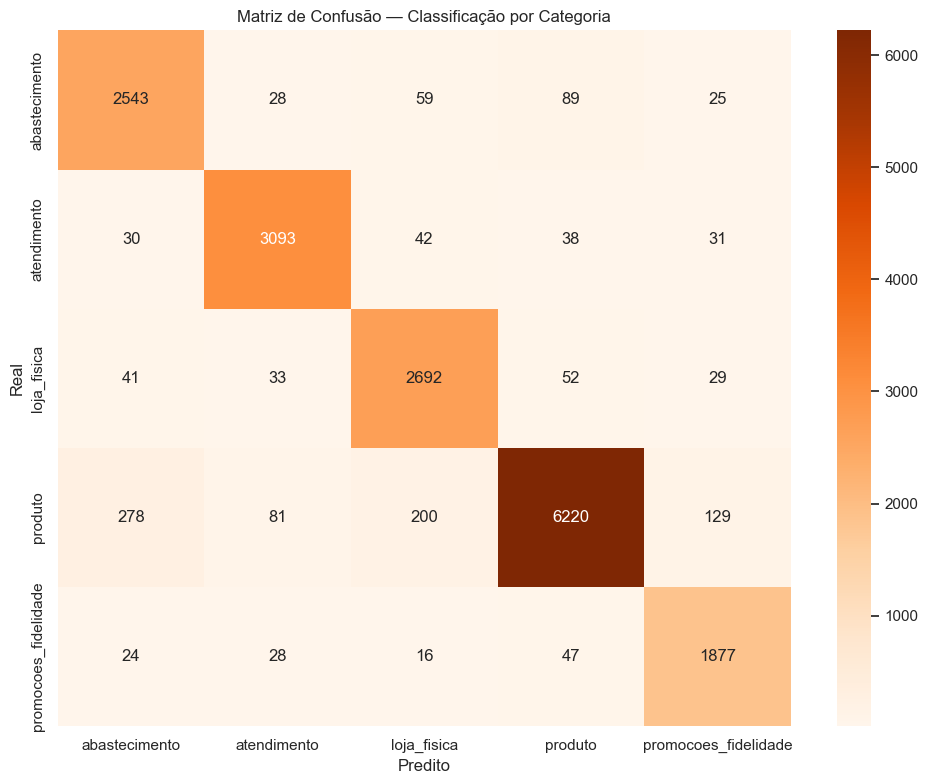



ANÁLISE DE ERROS — O que o modelo confunde?

Pior categoria: abastecimento (F1=0.899)
Erros nesta categoria: 201

Para onde o modelo está confundindo:
predito
produto                 89
loja_fisica             59
atendimento             28
promocoes_fidelidade    25

Exemplos de erros (primeiros 5):
  [abastecimento → produto] "não tinha dois itens como raquete e coração de boi"
  [abastecimento → loja_fisica] "comprei com entrega agendada não chegou no horario precisei falar com swift vezes para recebe o prod"
  [abastecimento → produto] "olá a carne moída não era de boa qualidade e não tinha no rótulo informação de qual era o corte para"
  [abastecimento → produto] "fazendo melhores promoções e ajustando os valores"
  [abastecimento → loja_fisica] "existe funcionários que não deviam estar trabalhando na rede não sabe atender não tem o mínimo de em"


In [55]:
# ── 15. Avaliação obrigatória ──────────────────────────────────────────────
print('CLASSIFICATION REPORT (por categoria)')
print('='*70)
print(classification_report(y_test, y_pred, digits=3))

# F1 por categoria — identificar piores
from sklearn.metrics import f1_score as _f1
labels_unicos = sorted(set(y_test))
f1_por_cat = {}
for cat in labels_unicos:
    f1_por_cat[cat] = _f1(y_test==cat, y_pred==cat)
f1_df = pd.DataFrame({'categoria': list(f1_por_cat.keys()), 'f1_score': list(f1_por_cat.values())})
f1_df = f1_df.sort_values('f1_score')

print(f'\nCategorias com PIOR desempenho:')
print(f1_df.head(3).to_string(index=False))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred, labels=labels_unicos)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=labels_unicos, yticklabels=labels_unicos)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Classificação por Categoria')
plt.tight_layout()
plt.show()

# Análise qualitativa de erros — categorias com pior F1
print(f'\n\nANÁLISE DE ERROS — O que o modelo confunde?')
print('='*70)
pior_cat = f1_df.iloc[0]['categoria']
mask_erro = (y_test != y_pred) & (y_test == pior_cat)
X_test_arr = np.array(X_test)
erros_pior = pd.DataFrame({'texto': X_test_arr[mask_erro], 'real': y_test[mask_erro], 'predito': y_pred[mask_erro]})
print(f'\nPior categoria: {pior_cat} (F1={f1_df.iloc[0]["f1_score"]:.3f})')
print(f'Erros nesta categoria: {len(erros_pior)}')
print(f'\nPara onde o modelo está confundindo:')
print(erros_pior['predito'].value_counts().to_string())
print(f'\nExemplos de erros (primeiros 5):')
for _, row in erros_pior.head(5).iterrows():
    print(f'  [{row["real"]} → {row["predito"]}] "{row["texto"][:100]}"')


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 16. Clusterização de Lojas por Perfil de Feedback</div>

Perfil dos clusters de lojas:
         n_lojas  nps_medio  transacoes_media
cluster                                      
0             51       75.0            6712.4
1             82       61.5            7222.2
2             94       71.3            7342.8


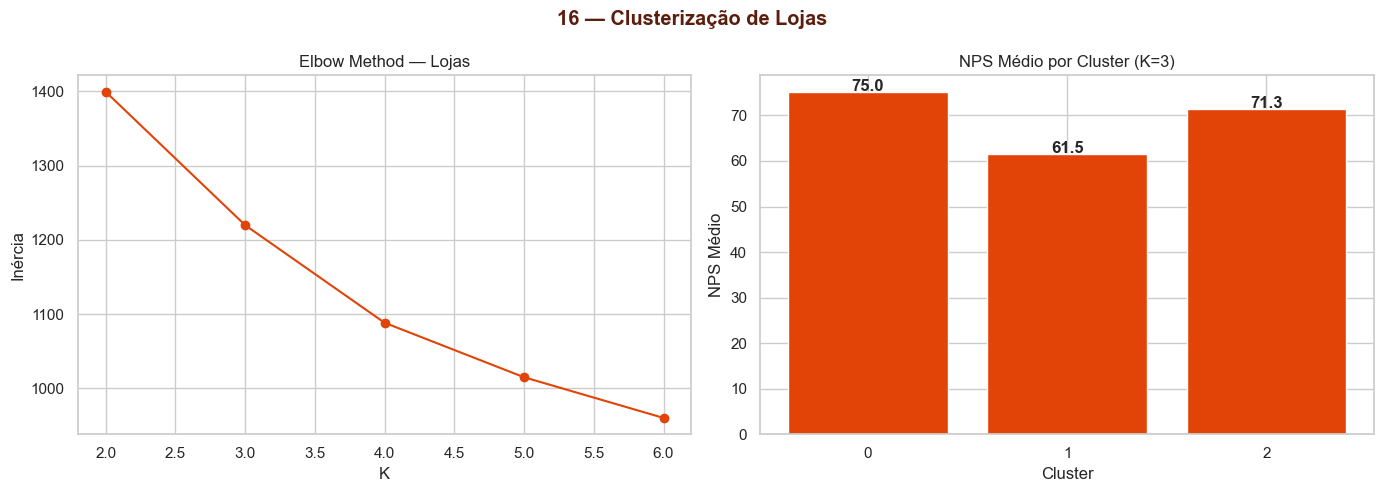


Distribuição de flags por cluster:
flag_dominante  REGULAR  TOCADORA
cluster                          
0                    40        11
1                    47        35
2                    82        12


In [56]:
# ── 16. Clusterização de lojas por região/perfil de feedback ────────────────
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Features por loja: % cada categoria + NPS + volume + flag
cat_dist = df.groupby(['centro_nv2','categoria']).size().unstack(fill_value=0)
cat_pct  = cat_dist.div(cat_dist.sum(axis=1), axis=0) * 100

# NPS por loja
nps_loja = df.groupby('centro_nv2').apply(
    lambda g: (g.loc[g['classificacao']=='promotor','qtd_clientes'].sum() - 
               g.loc[g['classificacao']=='detrator','qtd_clientes'].sum()) /
              g['qtd_clientes'].sum() * 100
).rename('nps')

# Volume médio de transações
trans_loja = df.dropna(subset=['transacoes']).groupby('centro_nv2')['transacoes'].mean().rename('transacoes_media')

# Flag dominante
flag_loja = df.groupby('centro_nv2')['flag'].agg(lambda x: x.mode().iloc[0] if len(x) > 0 else 'desconhecido').rename('flag_dominante')

# Montar feature matrix
loja_features = cat_pct.join(nps_loja).join(trans_loja).join(flag_loja).dropna()
loja_features_num = loja_features.drop(columns=['flag_dominante'])

# Escalar e clusterizar (K=3 para perfis: alto/médio/baixo desempenho)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(loja_features_num)

# Inércia para K=2..6
inercias = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append({'k': k, 'inertia': km.inertia_})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('16 — Clusterização de Lojas', fontweight='bold', color='#5c1d0c')

# Elbow
axes[0].plot([d['k'] for d in inercias], [d['inertia'] for d in inercias], marker='o', color='#E24307')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inércia')
axes[0].set_title('Elbow Method — Lojas')

# Modelo final K=3
K_LOJAS = 3
km_final = KMeans(n_clusters=K_LOJAS, random_state=42, n_init=10)
loja_features['cluster'] = km_final.fit_predict(X_scaled)

# Perfil dos clusters
perfil = loja_features.groupby('cluster').agg(
    n_lojas=('nps','count'), nps_medio=('nps','mean'),
    transacoes_media=('transacoes_media','mean')
).round(1)
print('Perfil dos clusters de lojas:')
print(perfil.to_string())

# NPS por cluster
cluster_nps = loja_features.groupby('cluster')['nps'].mean()
bars = axes[1].bar(cluster_nps.index.astype(str), cluster_nps.values, color='#E24307', edgecolor='white')
for bar, v in zip(bars, cluster_nps.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.1f}', ha='center', fontweight='bold')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('NPS Médio')
axes[1].set_title(f'NPS Médio por Cluster (K={K_LOJAS})')
plt.tight_layout()
plt.show()

# Flag por cluster
print(f'\nDistribuição de flags por cluster:')
print(loja_features.groupby(['cluster','flag_dominante']).size().unstack(fill_value=0).to_string())


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 17. Análise Complementar — Discordantes e Categorias por Flag</div>

EXEMPLOS DE DISCORDÂNCIA ENTRE ANOTADORES
Total discordâncias: 26

Primeiros 10 casos ambíguos:
  [abastecimento vs produto] "Senti falta de opções de carnes suinas"
  [abastecimento vs produto] "Não encontrei linguiça de pernil, e a picanha legado estava toda dura até mesmo "
  [entrega_logistica vs produto] "Tudo excelente, desde os produtos até a rapidez na entrega. Amei!"
  [atendimento vs loja_fisica] "Mais foncionario e uma loja 24 horas"
  [entrega_logistica vs atendimento] "Estive na loja de Bragança Paulista no ultimo domingo, sempre estou por la e o a"
  [ vs entrega_logistica] "Não concordei com a quantidade que mandaram e obviamente o preço foi além do que"
  [outros vs promocoes_fidelidade] "Poderiam dar brindes por comprar acima
Dos 100 reais"
  [abastecimento vs loja_fisica] "A loja na rua Tutoia esta sempre com falta de produtos e caixas e mais caixas de"
  [abastecimento vs produto] "Tirar os TRANGÊNICOS. Observei que esse produto tem aumentado muito na Swift"
  [loja_

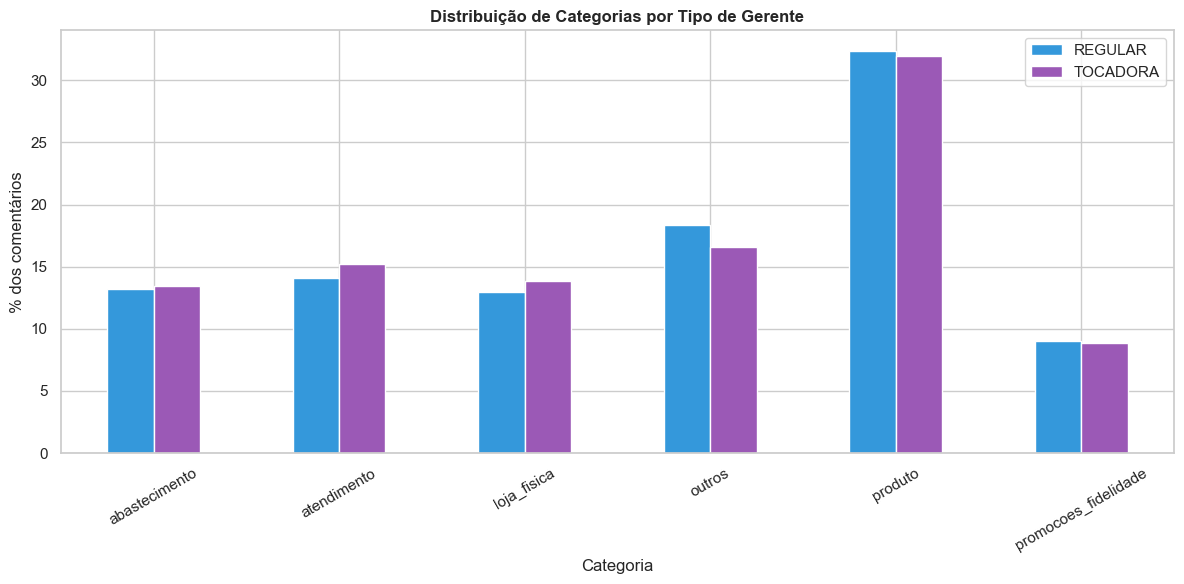

categoria  abastecimento  atendimento  loja_fisica  outros  produto  promocoes_fidelidade
flag                                                                                     
REGULAR             13.2         14.1         13.0    18.4     32.4                   9.0
TOCADORA            13.5         15.2         13.8    16.6     32.0                   8.9

Insight: categorias com maior diferença entre flags indicam
onde o perfil de gestão tem mais impacto na experiência do cliente.

TESTE CHI-SQUARE (independência)
  Estatística: 77.4
  Graus de liberdade: 5
  p-value: 0.000000

  [RESULTADO] Diferença ESTATISTICAMENTE SIGNIFICATIVA (p < 0.05)
  O perfil de gestão influencia o tipo de feedback recebido.

  Resíduos padronizados (|r| > 2 = diferença relevante):
categoria  abastecimento  atendimento  loja_fisica  outros  produto  promocoes_fidelidade
flag                                                                                     
REGULAR            -0.58        -2.22        -1

In [57]:
# ── 17a. Exemplos de discordância entre anotadores ─────────────────────────
print('EXEMPLOS DE DISCORDÂNCIA ENTRE ANOTADORES')
print('='*70)
if 'anotado' in dir() and len(anotado) > 0:
    disc = anotado[anotado[col1] != anotado[col2]].copy()
    print(f'Total discordâncias: {len(disc)}')
    print(f'\nPrimeiros 10 casos ambíguos:')
    for _, row in disc.head(10).iterrows():
        texto = str(row.get('COMENTARIO', row.get('comentario', '')))[:80]
        print(f'  [{row[col1]} vs {row[col2]}] "{texto}"')
    print(f'\nPares de categorias mais confundidos pelos anotadores:')
    disc['par'] = disc.apply(lambda r: tuple(sorted([r[col1], r[col2]])), axis=1)
    print(disc['par'].value_counts().head(5).to_string())
else:
    print('Dados de anotação não disponíveis. Execute a seção 11 primeiro.')

# ── 17b. Distribuição de categorias por flag REGULAR vs TOCADORA ────────────
print(f'\n\nDISTRIBUIÇÃO DE CATEGORIAS POR FLAG')
print('='*70)
cat_flag = df.groupby(['flag','categoria']).size().unstack(fill_value=0)
cat_flag_pct = cat_flag.div(cat_flag.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
cat_flag_pct.T.plot(kind='bar', ax=ax, color=['#3498db','#9b59b6'], edgecolor='white')
ax.set_title('Distribuição de Categorias por Tipo de Gerente', fontweight='bold')
ax.set_xlabel('Categoria')
ax.set_ylabel('% dos comentários')
ax.legend(['REGULAR','TOCADORA'])
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print(cat_flag_pct.round(1).to_string())
print(f'\nInsight: categorias com maior diferença entre flags indicam')
print(f'onde o perfil de gestão tem mais impacto na experiência do cliente.')


# ── Teste Chi-Square: diferença estatística entre REGULAR e TOCADORA ────────
from scipy.stats import chi2_contingency

stat, p, dof, expected = chi2_contingency(cat_flag)
print(f'\nTESTE CHI-SQUARE (independência)')
print(f'  Estatística: {stat:.1f}')
print(f'  Graus de liberdade: {dof}')
print(f'  p-value: {p:.6f}')
print()
if p < 0.05:
    print(f'  [RESULTADO] Diferença ESTATISTICAMENTE SIGNIFICATIVA (p < 0.05)')
    print(f'  O perfil de gestão influencia o tipo de feedback recebido.')
    # Calcular resíduos padronizados para identificar onde está a diferença
    # numpy já importado acima
    residuos = (cat_flag.values - expected) / np.sqrt(expected)
    df_residuos = pd.DataFrame(residuos, index=cat_flag.index, columns=cat_flag.columns)
    print(f'\n  Resíduos padronizados (|r| > 2 = diferença relevante):')
    print(df_residuos.round(2).to_string())
else:
    print(f'  [RESULTADO] Sem diferença significativa (p = {p:.4f} > 0.05)')
    print(f'  O perfil de gestão (REGULAR vs TOCADORA) NÃO altera')
    print(f'  significativamente a distribuição de categorias de feedback.')
    print(f'  Isso indica que os temas dos comentários refletem a LOJA,')
    print(f'  não o tipo de gerente.')
